In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

## Handwritten Digits

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

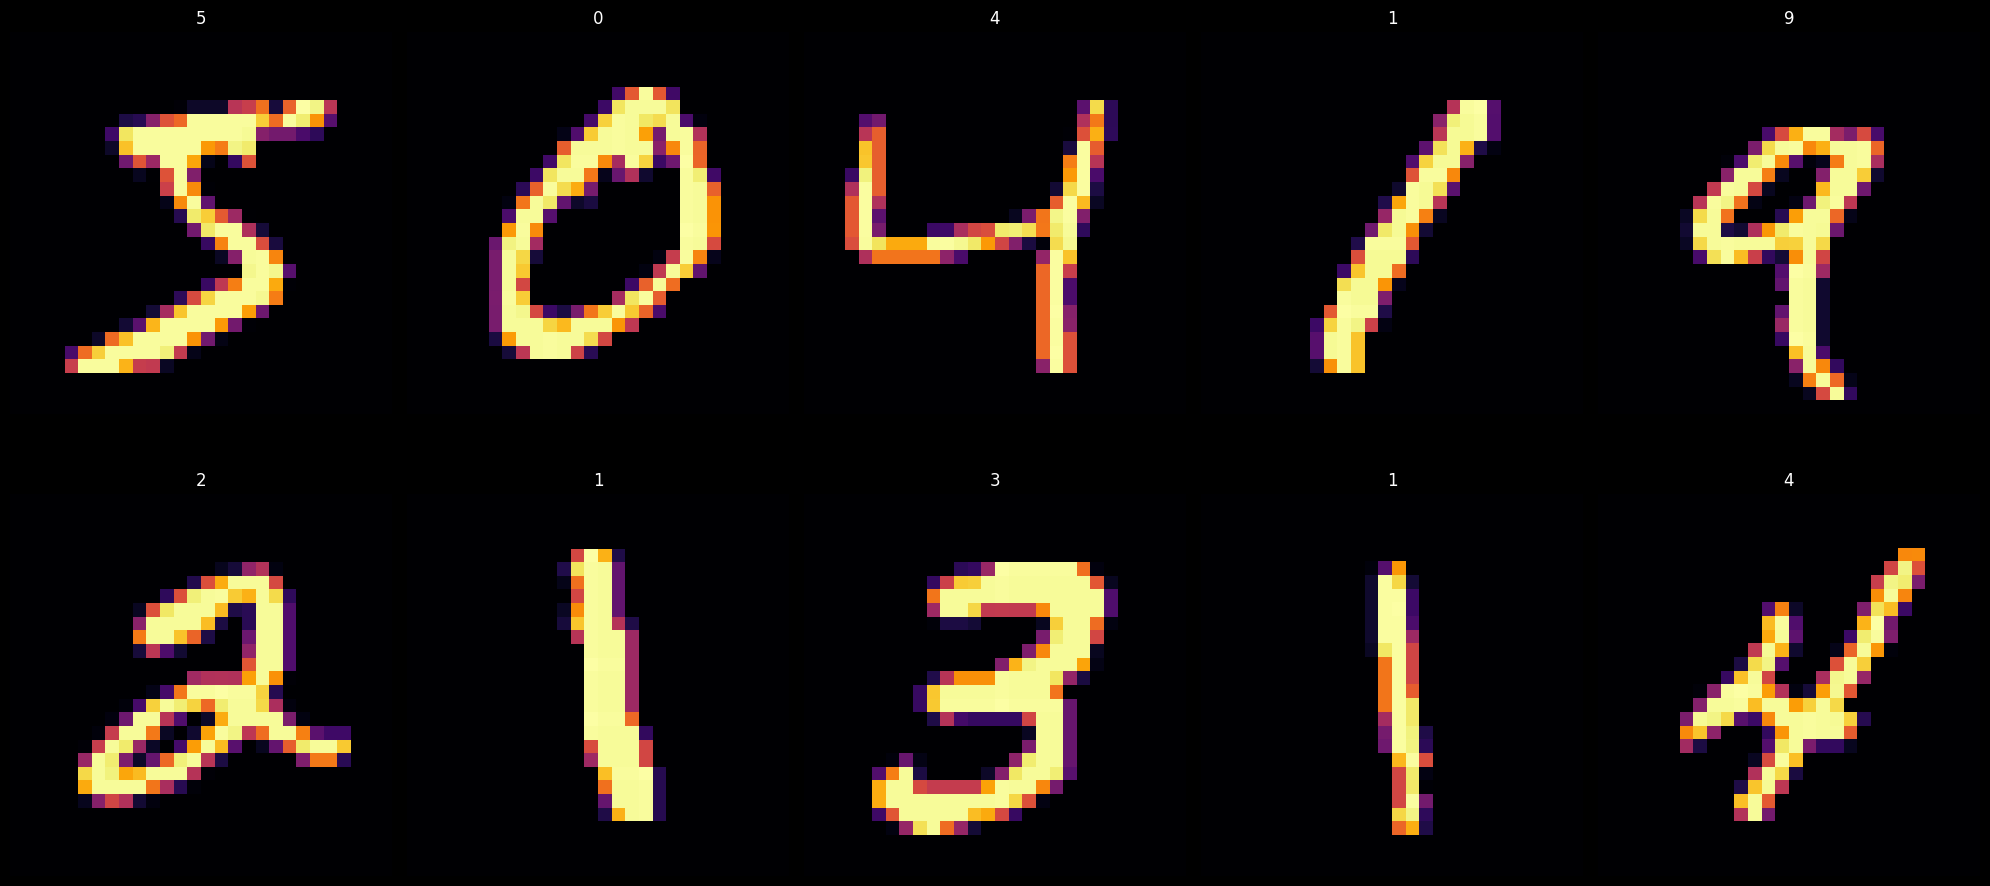

In [5]:
plt.figure(figsize=(20, 10))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(X_train[i], cmap="inferno")
    ax.set_title(str(y_train[i]))
    ax.axis("off")


plt.tight_layout()
plt.show()


In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0


### ANN

In [7]:
ann = keras.Sequential(
    [
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [8]:
ann.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [9]:
ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 696us/step - accuracy: 0.9222 - loss: 0.2761
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 619us/step - accuracy: 0.9640 - loss: 0.1221
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step - accuracy: 0.9742 - loss: 0.0863
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.9800 - loss: 0.0655
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - accuracy: 0.9838 - loss: 0.0525


In [10]:
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - accuracy: 0.9760 - loss: 0.0776


[0.07763958722352982, 0.9760000109672546]

In [11]:
import numpy as np

y_hat = ann.predict(X_test)
y_hat = [np.argmax(y) for y in y_hat]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_hat))


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.98      0.96      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.97      0.97       892
           6       0.97      0.99      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.96      0.97      0.96       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### CNN


In [13]:
cnn = keras.Sequential(
    [
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(32, 3, activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [14]:
cnn.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [15]:
cnn.fit(X_train, y_train, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9541 - loss: 0.1544
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9849 - loss: 0.0510
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0335
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9932 - loss: 0.0219
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9952 - loss: 0.0151


In [16]:
cnn.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.9837 - loss: 0.0547


[0.054715242236852646, 0.9836999773979187]

In [17]:
import numpy as np

y_hat = ann.predict(X_test)
y_hat = [np.argmax(y) for y in y_hat]


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_hat))


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.98      0.96      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.97      0.97       892
           6       0.97      0.99      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.96      0.97      0.96       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## CIFAR10


In [19]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [20]:
y_train = y_train.reshape(
    -1,
)
y_test = y_test.reshape(
    -1,
)

In [21]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]


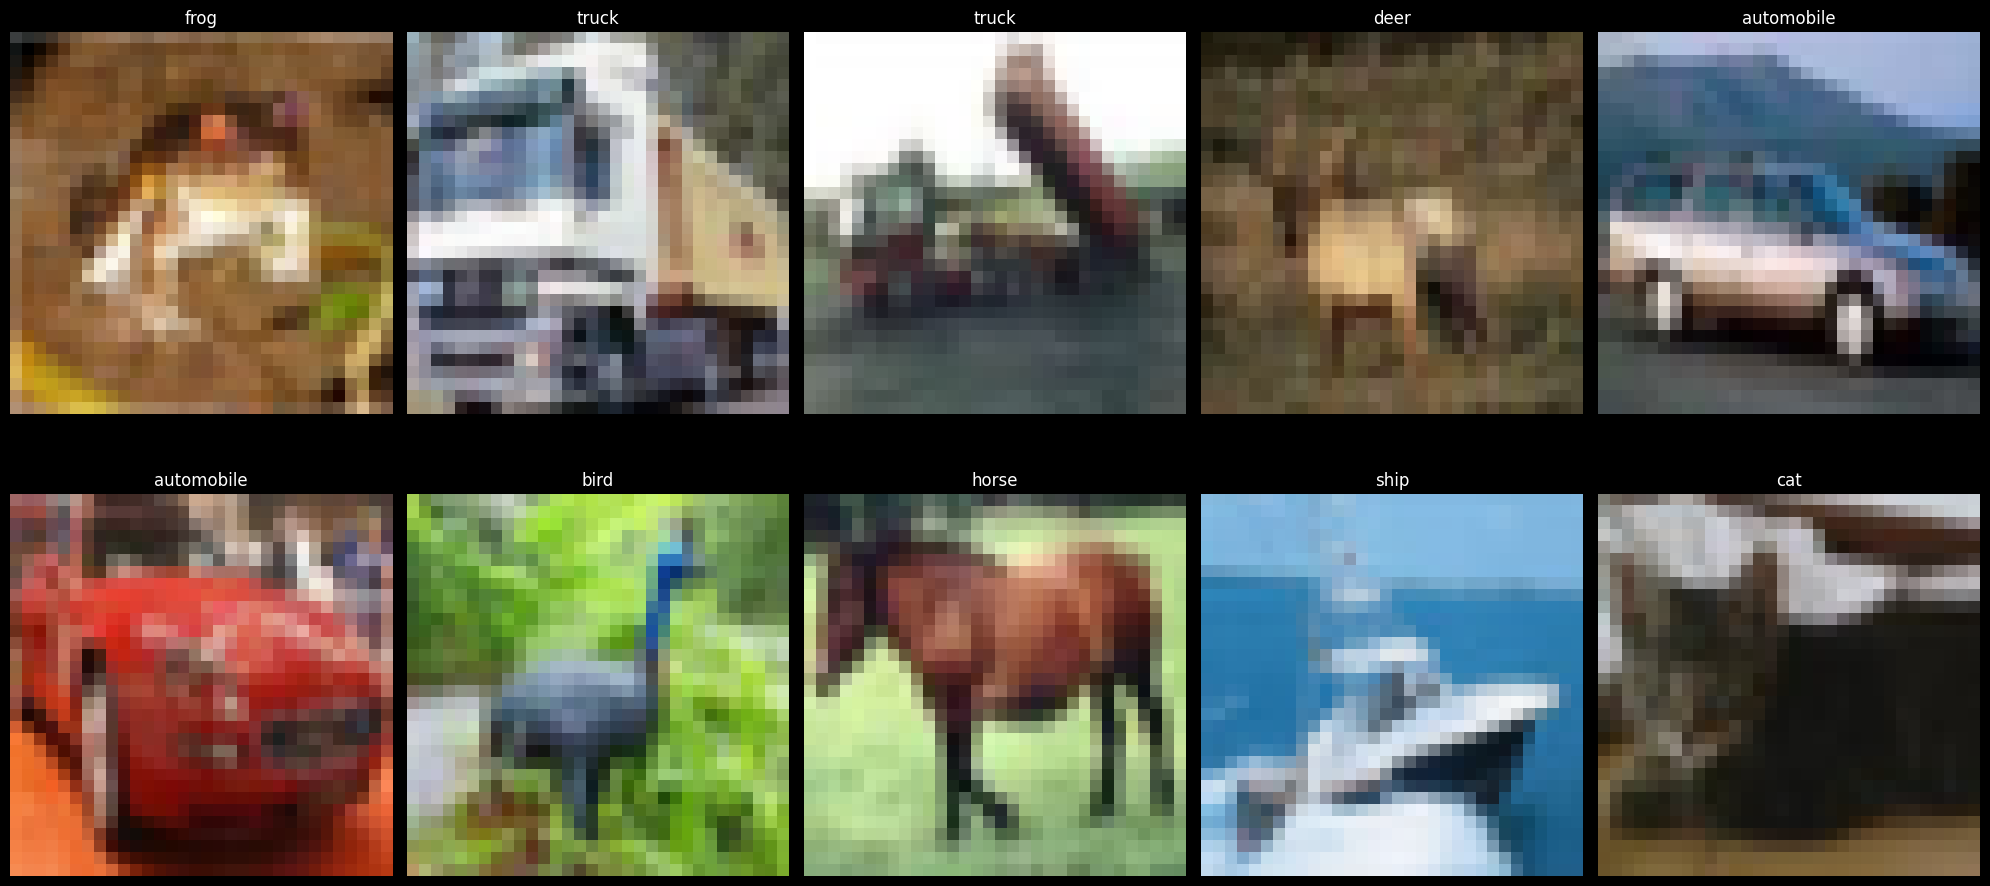

In [22]:
plt.figure(figsize=(20, 10))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(X_train[i])
    ax.set_title(classes[y_train[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [23]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### ANN


In [24]:
ann = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [25]:
ann.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [26]:
ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3206 - loss: 1.8792
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3921 - loss: 1.6801
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4230 - loss: 1.6045
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4453 - loss: 1.5506
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4532 - loss: 1.5234


In [27]:
y_hat = ann.predict(X_test)
y_hat = [np.argmax(y) for y in y_hat]
print(classification_report(y_test, y_hat))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step
              precision    recall  f1-score   support

           0       0.60      0.39      0.47      1000
           1       0.69      0.39      0.50      1000
           2       0.35      0.39      0.37      1000
           3       0.31      0.31      0.31      1000
           4       0.38      0.36      0.37      1000
           5       0.43      0.27      0.33      1000
           6       0.38      0.70      0.50      1000
           7       0.59      0.40      0.47      1000
           8       0.50      0.70      0.58      1000
           9       0.50      0.60      0.54      1000

    accuracy                           0.45     10000
   macro avg       0.47      0.45      0.44     10000
weighted avg       0.47      0.45      0.44     10000



### CNN


In [28]:
cnn = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Conv2D(32, 3, activation="relu"),
        keras.layers.MaxPool2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [29]:
cnn.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [30]:
cnn.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4940 - loss: 1.4079
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6187 - loss: 1.0822
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6862 - loss: 0.8902
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7406 - loss: 0.7283
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7936 - loss: 0.5860


In [31]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6514 - loss: 1.0602


[1.060186505317688, 0.6514000296592712]

In [32]:
y_hat = cnn.predict(X_test)
y_hat = [np.argmax(y) for y in y_hat]
print(classification_report(y_test, y_hat))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.70      0.73      0.72      1000
           1       0.80      0.75      0.78      1000
           2       0.53      0.51      0.52      1000
           3       0.46      0.44      0.45      1000
           4       0.56      0.58      0.57      1000
           5       0.54      0.59      0.56      1000
           6       0.72      0.70      0.71      1000
           7       0.67      0.77      0.72      1000
           8       0.82      0.73      0.77      1000
           9       0.74      0.71      0.72      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.65     10000
weighted avg       0.65      0.65      0.65     10000

